# Face Mask Detection using Image Processing


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder
from PIL import Image

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# Create output directory for saving results
os.makedirs('output_images', exist_ok=True)

# Verify dataset folders exist and count images
with_mask_dir    = 'dataset/with_mask'
without_mask_dir = 'dataset/without_mask'

assert os.path.isdir(with_mask_dir),    f"Folder not found: {with_mask_dir}"
assert os.path.isdir(without_mask_dir), f"Folder not found: {without_mask_dir}"

with_mask_count    = len([f for f in os.listdir(with_mask_dir)    if f.lower().endswith(('.jpg','.jpeg','.png'))])
without_mask_count = len([f for f in os.listdir(without_mask_dir) if f.lower().endswith(('.jpg','.jpeg','.png'))])

print(f"  Dataset loaded successfully!")
print(f"  With mask images   : {with_mask_count}")
print(f"  Without mask images: {without_mask_count}")
print(f"  Total              : {with_mask_count + without_mask_count}")


  Dataset loaded successfully!
  With mask images   : 3725
  Without mask images: 3828
  Total              : 7553


## Load and Display Sample Images

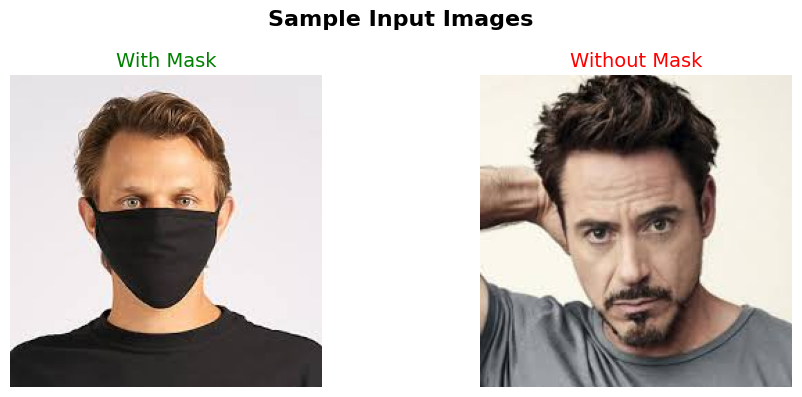

Sample images displayed and saved.


In [3]:
def load_image(path):
    """Load image using OpenCV and convert BGR to RGB."""
    img = cv2.imread(path)
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Selected sample images
mask_path    = 'dataset/with_mask/with_mask_837.jpg'
no_mask_path = 'dataset/without_mask/without_mask_992.jpg'

mask_sample    = load_image(mask_path)
no_mask_sample = load_image(no_mask_path)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(mask_sample)
axes[0].set_title('With Mask', fontsize=14, color='green')
axes[0].axis('off')
axes[1].imshow(no_mask_sample)
axes[1].set_title('Without Mask', fontsize=14, color='red')
axes[1].axis('off')
plt.suptitle('Sample Input Images', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('output_images/01_sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print("Sample images displayed and saved.")


##  Image Preprocessing Pipeline


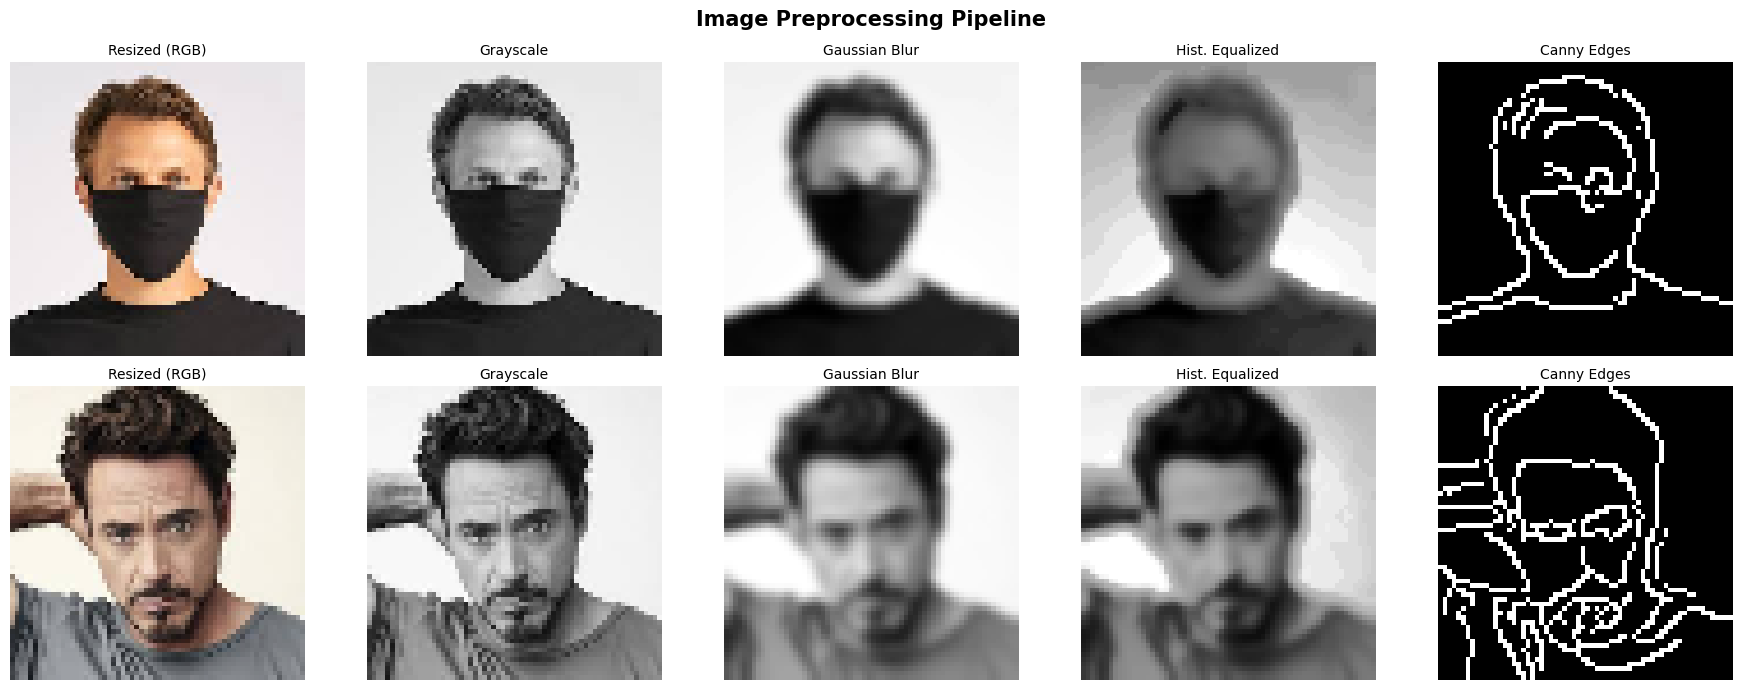

Preprocessing pipeline saved.


In [4]:
def preprocess_image(img_bgr, target_size=(64, 64)):
    """
    Full preprocessing pipeline:
    1. Resize to uniform size
    2. Convert to grayscale
    3. Apply Gaussian blur (noise reduction)
    4. Histogram equalization (contrast enhancement)
    5. Edge detection using Canny
    """
    resized   = cv2.resize(img_bgr, target_size)
    gray      = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)
    blurred   = cv2.GaussianBlur(gray, (5, 5), 0)
    equalized = cv2.equalizeHist(blurred)
    edges     = cv2.Canny(equalized, threshold1=50, threshold2=150)
    return resized, gray, blurred, equalized, edges

sample_bgr_mask    = cv2.imread('dataset/with_mask/with_mask_837.jpg')
sample_bgr_no_mask = cv2.imread('dataset/without_mask/without_mask_992.jpg')

stages_mask    = preprocess_image(sample_bgr_mask)
stages_no_mask = preprocess_image(sample_bgr_no_mask)

stage_names = ['Resized (RGB)', 'Grayscale', 'Gaussian Blur', 'Hist. Equalized', 'Canny Edges']
cmaps       = [None, 'gray', 'gray', 'gray', 'gray']

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
labels     = ['With Mask', 'Without Mask']
all_stages = [stages_mask, stages_no_mask]

for row in range(2):
    for col in range(5):
        img = all_stages[row][col]
        if col == 0:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[row][col].imshow(img, cmap=cmaps[col])
        axes[row][col].set_title(stage_names[col], fontsize=10)
        axes[row][col].axis('off')
        if col == 0:
            axes[row][col].set_ylabel(labels[row], fontsize=12, fontweight='bold')

plt.suptitle('Image Preprocessing Pipeline', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('output_images/02_preprocessing.png', dpi=150, bbox_inches='tight')
plt.show()
print("Preprocessing pipeline saved.")


##  Feature Extraction


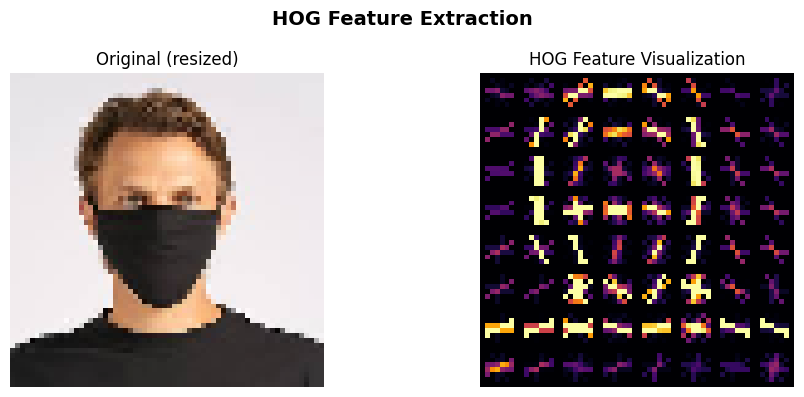

HOG visualization saved.


In [5]:
from skimage.feature import hog
from skimage import exposure

def extract_features(img_bgr, target_size=(64, 64)):
    """
    Extract combined features from an image:
    - HOG features (shape/texture)
    - Color histogram in HSV (color distribution)
    """
    resized = cv2.resize(img_bgr, target_size)
    gray    = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)
    gray_eq = cv2.equalizeHist(cv2.GaussianBlur(gray, (5,5), 0))

    hog_features = hog(
        gray_eq,
        orientations=8,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        visualize=False,
        feature_vector=True
    )

    hsv        = cv2.cvtColor(resized, cv2.COLOR_BGR2HSV)
    color_hist = []
    for channel in range(3):
        hist = cv2.calcHist([hsv], [channel], None, [32], [0, 256])
        color_hist.extend(hist.flatten())
    color_hist = np.array(color_hist)
    color_hist = color_hist / (color_hist.sum() + 1e-6)

    return np.concatenate([hog_features, color_hist])

# HOG visualization on selected sample
sample_bgr  = cv2.imread('dataset/with_mask/with_mask_837.jpg')
sample_gray = cv2.cvtColor(cv2.resize(sample_bgr, (64,64)), cv2.COLOR_BGR2GRAY)
sample_gray = cv2.equalizeHist(cv2.GaussianBlur(sample_gray, (5,5), 0))

_, hog_image = hog(sample_gray, orientations=8, pixels_per_cell=(8,8),
                   cells_per_block=(2,2), visualize=True, feature_vector=True)
hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(cv2.cvtColor(cv2.resize(sample_bgr, (64,64)), cv2.COLOR_BGR2RGB))
axes[0].set_title('Original (resized)', fontsize=12)
axes[0].axis('off')
axes[1].imshow(hog_image_rescaled, cmap='inferno')
axes[1].set_title('HOG Feature Visualization', fontsize=12)
axes[1].axis('off')
plt.suptitle('HOG Feature Extraction', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('output_images/03_hog_features.png', dpi=150, bbox_inches='tight')
plt.show()
print("HOG visualization saved.")


## Build Dataset and Train Classifier

In [6]:

X = []  # feature vectors
y = []  # labels

categories = {
    'dataset/with_mask':    'with_mask',
    'dataset/without_mask': 'without_mask'
}

for folder, label in categories.items():
    for filename in os.listdir(folder):
        if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
            img_path = os.path.join(folder, filename)
            img = cv2.imread(img_path)
            if img is not None:
                features = extract_features(img)
                X.append(features)
                y.append(label)

X = np.array(X)
y = np.array(y)

print(f"Total samples      : {len(X)}")
print(f"Feature vector size: {X.shape[1]}")
print(f"Classes            : {np.unique(y)}")

Total samples      : 7553
Feature vector size: 1664
Classes            : ['with_mask' 'without_mask']


In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Split into train and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Build pipeline: scaler + SVM classifier
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm',    SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42))
])

# Train the model
pipeline.fit(X_train, y_train)

# Evaluate
y_pred    = pipeline.predict(X_test)
accuracy  = accuracy_score(y_test, y_pred)

print(f"\nTest Accuracy: {accuracy * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Test Accuracy: 88.75%

Classification Report:
              precision    recall  f1-score   support

   with_mask       0.87      0.91      0.89       745
without_mask       0.91      0.87      0.89       766

    accuracy                           0.89      1511
   macro avg       0.89      0.89      0.89      1511
weighted avg       0.89      0.89      0.89      1511



##  Visualize Predictions

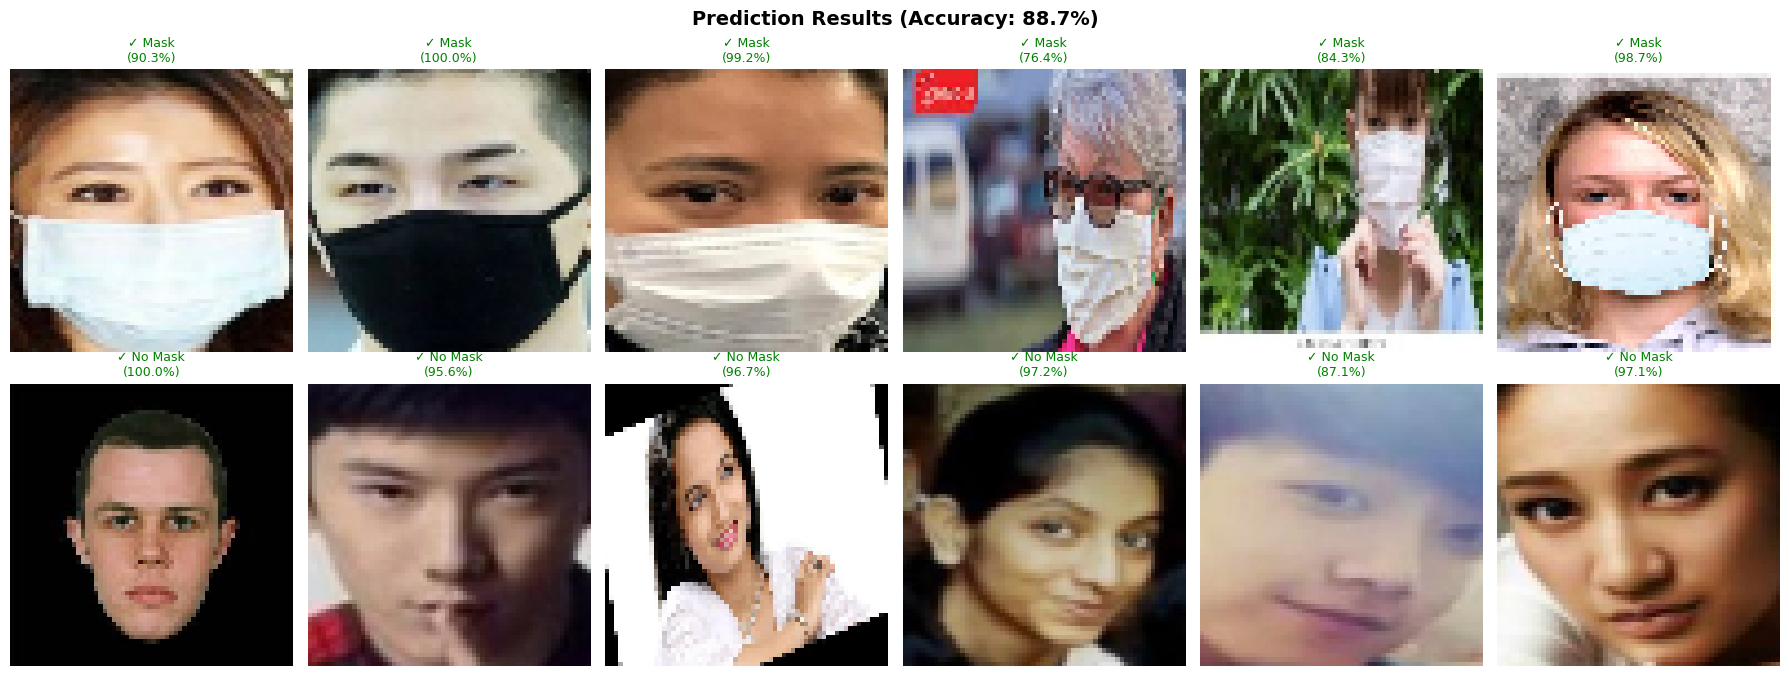

Prediction visualization saved.


In [8]:
all_paths  = []
all_labels = []

for folder, label in categories.items():
    for filename in sorted(os.listdir(folder)):
        if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
            all_paths.append(os.path.join(folder, filename))
            all_labels.append(label)

from sklearn.model_selection import train_test_split as tts
_, test_paths, _, test_true_labels = tts(
    all_paths, all_labels, test_size=0.2, random_state=42, stratify=all_labels
)

# Show 12 samples: 6 with_mask + 6 without_mask from test set
sample_with    = [p for p, l in zip(test_paths, test_true_labels) if l == 'with_mask'][:6]
sample_without = [p for p, l in zip(test_paths, test_true_labels) if l == 'without_mask'][:6]
viz_paths      = sample_with + sample_without
viz_labels     = ['with_mask']*6 + ['without_mask']*6

fig, axes = plt.subplots(2, 6, figsize=(18, 7))
axes = axes.flatten()

for idx, (img_path, true_label) in enumerate(zip(viz_paths, viz_labels)):
    img_bgr    = cv2.imread(img_path)
    features   = extract_features(img_bgr).reshape(1, -1)
    pred_label = pipeline.predict(features)[0]
    confidence = pipeline.predict_proba(features).max() * 100

    img_rgb = cv2.cvtColor(cv2.resize(img_bgr, (64,64)), cv2.COLOR_BGR2RGB)
    axes[idx].imshow(img_rgb)

    color       = 'green' if pred_label == true_label else 'red'
    status      = '\u2713' if pred_label == true_label else '\u2717'
    label_short = 'Mask' if pred_label == 'with_mask' else 'No Mask'
    axes[idx].set_title(f"{status} {label_short}\n({confidence:.1f}%)", fontsize=9, color=color)
    axes[idx].axis('off')

plt.suptitle(f'Prediction Results (Accuracy: {accuracy*100:.1f}%)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('output_images/04_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Prediction visualization saved.")


##  Confusion Matrix

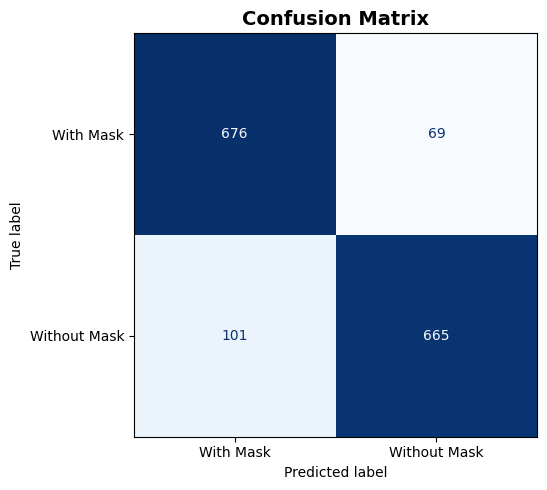

Confusion matrix saved.


In [9]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test, y_pred, labels=['with_mask', 'without_mask'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['With Mask', 'Without Mask'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('output_images/05_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrix saved.")

##  Color Histogram Comparison

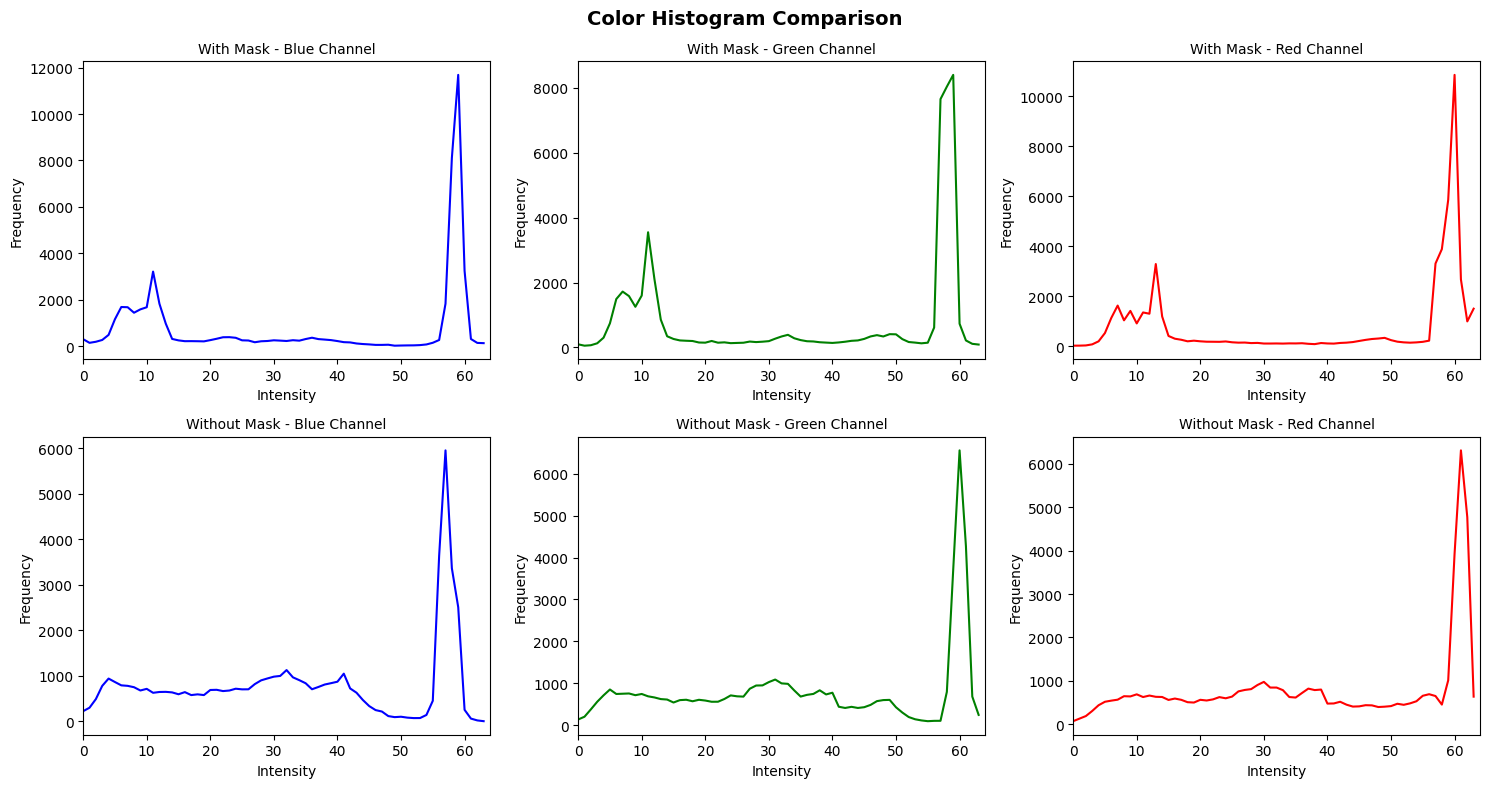

Color histogram comparison saved.


In [10]:
def plot_color_histogram(img_bgr, title, ax_list):
    colors        = ('b', 'g', 'r')
    channel_names = ('Blue', 'Green', 'Red')
    for i, (col, name) in enumerate(zip(colors, channel_names)):
        hist = cv2.calcHist([img_bgr], [i], None, [64], [0, 256])
        ax_list[i].plot(hist, color=col)
        ax_list[i].set_xlim([0, 64])
        ax_list[i].set_title(f'{title} - {name} Channel', fontsize=10)
        ax_list[i].set_xlabel('Intensity')
        ax_list[i].set_ylabel('Frequency')

mask_img    = cv2.imread('dataset/with_mask/with_mask_837.jpg')
no_mask_img = cv2.imread('dataset/without_mask/without_mask_992.jpg')

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
plot_color_histogram(mask_img,    'With Mask',    axes[0])
plot_color_histogram(no_mask_img, 'Without Mask', axes[1])

plt.suptitle('Color Histogram Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('output_images/06_color_histograms.png', dpi=150, bbox_inches='tight')
plt.show()
print("Color histogram comparison saved.")


In [11]:
# Final summary of results
print("=" * 50)
print("FACE MASK DETECTION - RESULTS SUMMARY")
print("=" * 50)
print(f"Total images      : {len(X)}")
print(f"Training samples  : {len(X_train)}")
print(f"Test samples      : {len(X_test)}")
print(f"Feature vector    : {X.shape[1]} dimensions")
print(f"Test Accuracy     : {accuracy * 100:.2f}%")
print("=" * 50)
print("All output images saved to: output_images/")


FACE MASK DETECTION - RESULTS SUMMARY
Total images      : 7553
Training samples  : 6042
Test samples      : 1511
Feature vector    : 1664 dimensions
Test Accuracy     : 88.75%
All output images saved to: output_images/
